# 0. 라이브러리 불러오기

In [1]:
import pandas as pd                    # CSV 데이터 처리
import numpy as np                     # 배열 연산
import matplotlib.pyplot as plt        # 시각화
import seaborn as sns                  # 시각화

import torch                           # PyTorch 기본 라이브러리
import torch.nn as nn                  # 신경망 계층 구성
import torch.optim as optim            # 최적화 알고리즘

from sklearn.model_selection import train_test_split  # 학습/검증 데이터 분리
from sklearn.preprocessing import LabelEncoder, StandardScaler  # 인코딩, 스케일링
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# GPU 사용 가능하면 GPU 사용, 아니면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)

사용 장치: cpu


# 1. 데이터 로드

In [6]:
# Colab에 train.csv, test.csv를 업로드한 후 실행
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# 데이터 앞 5행 확인
print(train_df.head())

# 데이터 구조 확인
print(train_df.info())

# 결측치 확인
print(train_df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

# 2. 결측치 처리

In [7]:
# Age 결측치는 평균 나이로 채움
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].mean())

# Embarked 결측치는 가장 많이 등장한 값으로 채움
train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])

# Cabin 결측치는 Unknown 문자열로 채움
train_df["Cabin"] = train_df["Cabin"].fillna("Unknown")

# 결측치 처리 결과 확인
print(train_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


# 3. 사용할 컬럼 정의

In [8]:
# 모델 학습에 사용하지 않을 컬럼
COL_DEL = ["PassengerId", "Name", "Ticket", "Cabin"]

# 수치형 컬럼
COL_NUM = ["Age", "Fare"]

# 범주형 컬럼
COL_CAT = ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]

# 정답 컬럼
COL_Y = "Survived"

# 4. 데이터 시각화

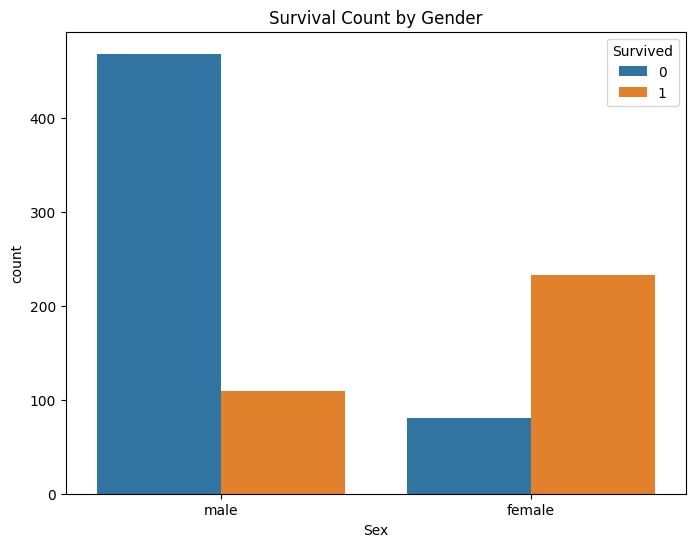

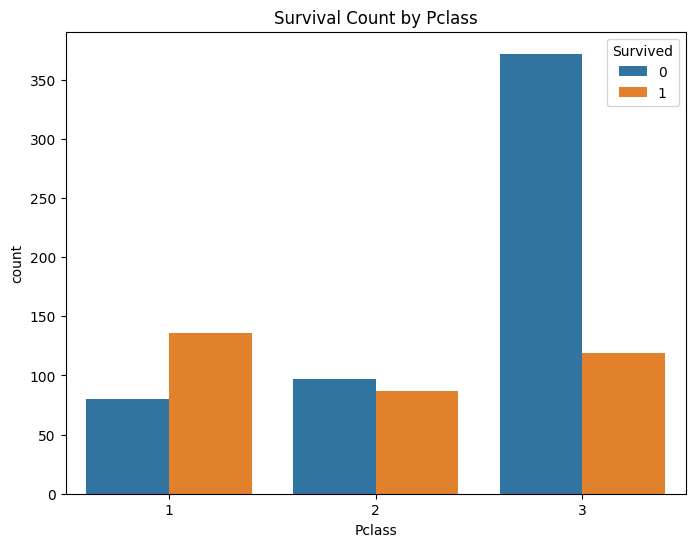

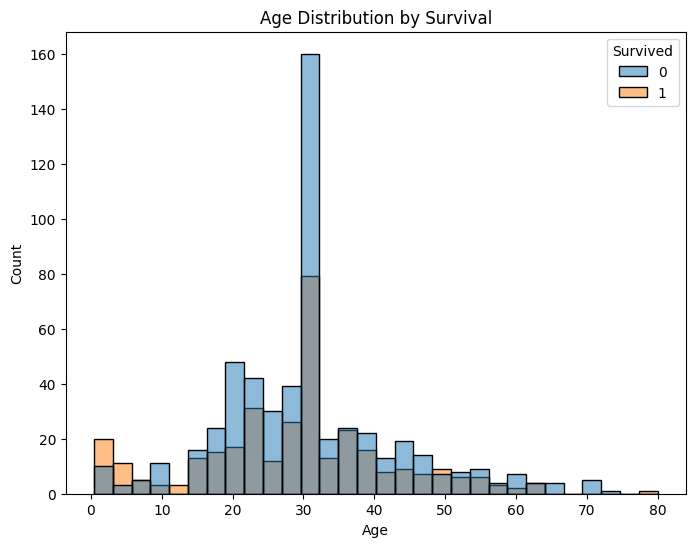

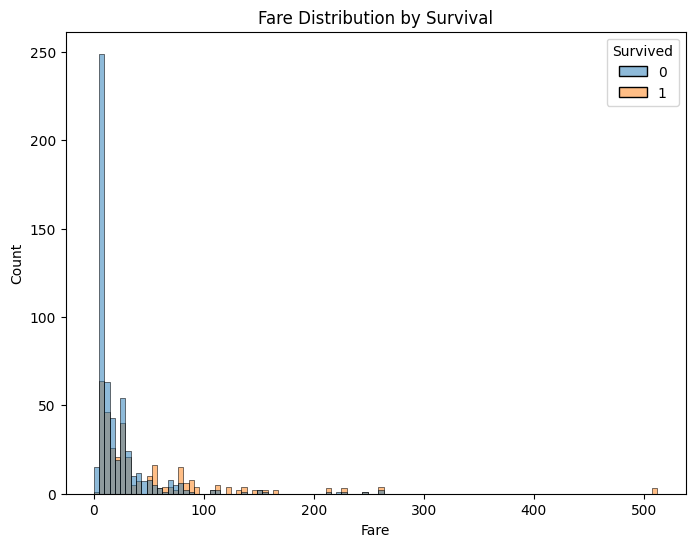

In [9]:
# 성별에 따른 생존 여부 확인
plt.figure(figsize=(8, 6))
sns.countplot(x="Sex", hue="Survived", data=train_df)
plt.title("Survival Count by Gender")
plt.show()

# 객실 등급에 따른 생존 여부 확인
plt.figure(figsize=(8, 6))
sns.countplot(x="Pclass", hue="Survived", data=train_df)
plt.title("Survival Count by Pclass")
plt.show()

# 나이에 따른 생존 분포 확인
plt.figure(figsize=(8, 6))
sns.histplot(x="Age", hue="Survived", data=train_df)
plt.title("Age Distribution by Survival")
plt.show()

# 요금에 따른 생존 분포 확인
plt.figure(figsize=(8, 6))
sns.histplot(x="Fare", hue="Survived", data=train_df)
plt.title("Fare Distribution by Survival")
plt.show()

# 5. 범주형 데이터 인코딩

In [10]:
# LabelEncoder를 컬럼별로 따로 저장
# test 데이터에도 같은 인코더를 적용하기 위해 딕셔너리 사용
label_encoders = {}

for col in COL_CAT:
    le = LabelEncoder()

    # 문자열 또는 범주형 값을 숫자로 변환
    train_df[col] = le.fit_transform(train_df[col])

    # 나중에 test 데이터 변환에 사용하기 위해 저장
    label_encoders[col] = le

    print(f"{col} 인코딩 완료")

Pclass 인코딩 완료
Sex 인코딩 완료
SibSp 인코딩 완료
Parch 인코딩 완료
Embarked 인코딩 완료


# 6. 수치형 데이터 스케일링

In [11]:
# StandardScaler는 평균 0, 표준편차 1 형태로 변환
scaler = StandardScaler()

# Age, Fare 컬럼 스케일링
train_df[COL_NUM] = scaler.fit_transform(train_df[COL_NUM])

print(train_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       2   
1            2         1       0   
2            3         1       2   
3            4         1       0   
4            5         0       2   

                                                Name  Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    1 -0.592481      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  0.638789      1   
2                             Heikkinen, Miss. Laina    0 -0.284663      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.407926      1   
4                           Allen, Mr. William Henry    1  0.407926      0   

   Parch            Ticket      Fare    Cabin  Embarked  
0      0         A/5 21171 -0.502445  Unknown         2  
1      0          PC 17599  0.786845      C85         0  
2      0  STON/O2. 3101282 -0.488854  Unknown         2  
3      0            113803  0.420730     C123         2  
4      0            3734

# 7. 학습 데이터와 테스트 데이터 분리

In [12]:
# 입력 데이터 X
X = train_df.drop(COL_DEL + [COL_Y], axis=1)

# 정답 데이터 y
y = train_df[COL_Y]

# 학습용 80%, 검증용 20%로 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (712, 7)
X_valid shape: (179, 7)
y_train shape: (712,)
y_valid shape: (179,)


# 8. PyTorch Tensor 변환

In [13]:
# 입력 데이터는 float32 타입 사용
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_valid_tensor = torch.tensor(X_valid.values, dtype=torch.float32).to(device)

# 정답 데이터는 CrossEntropyLoss 사용을 위해 long 타입 사용
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.long).to(device)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

X_train_tensor: torch.Size([712, 7])
y_train_tensor: torch.Size([712])


# 9. PyTorch 분류 모델 정의

In [14]:
class TitanicClassifier(nn.Module):
    def __init__(self, input_dim):
        # 부모 클래스 nn.Module 초기화
        super().__init__()

        # 첫 번째 완전연결층
        self.fc1 = nn.Linear(input_dim, 32)

        # 두 번째 완전연결층
        self.fc2 = nn.Linear(32, 16)

        # 출력층
        # 타이타닉 생존 여부는 0 또는 1이므로 클래스 개수는 2개
        self.fc3 = nn.Linear(16, 2)

        # 활성화 함수 ReLU
        self.relu = nn.ReLU()

        # 과적합 방지를 위한 Dropout
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # 입력층 → 은닉층1 → ReLU
        x = self.relu(self.fc1(x))

        # Dropout 적용
        x = self.dropout(x)

        # 은닉층1 → 은닉층2 → ReLU
        x = self.relu(self.fc2(x))

        # 출력층
        # CrossEntropyLoss는 내부에서 Softmax를 처리하므로 여기서는 Softmax를 쓰지 않음
        x = self.fc3(x)

        return x


# 입력 특성 개수
input_dim = X_train.shape[1]

# 모델 생성
model = TitanicClassifier(input_dim).to(device)

print(model)

TitanicClassifier(
  (fc1): Linear(in_features=7, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


# 10. 손실 함수와 최적화 함수 설정

In [15]:
# 다중 클래스 분류용 손실 함수
# 생존/사망 2개 클래스 분류에도 사용 가능
criterion = nn.CrossEntropyLoss()

# Adam 최적화 알고리즘 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 11. 모델 학습

In [18]:
epochs = 300

train_loss_history = []
valid_loss_history = []

for epoch in range(epochs):
    # -----------------------------
    # 학습 단계
    # -----------------------------

    # 모델을 학습 모드로 설정
    model.train()

    # 이전 epoch에서 계산된 기울기 초기화
    optimizer.zero_grad()

    # 학습 데이터 예측
    outputs = model(X_train_tensor)

    # 손실 계산
    loss = criterion(outputs, y_train_tensor)

    # 역전파 수행
    loss.backward()

    # 가중치 업데이트
    optimizer.step()

    # 학습 손실 저장
    train_loss_history.append(loss.item())

     # -----------------------------
    # 검증 단계
    # -----------------------------

    # 모델을 평가 모드로 설정
    model.eval()

    # 검증 단계에서는 기울기 계산 불필요
    with torch.no_grad():
        valid_outputs = model(X_valid_tensor)
        valid_loss = criterion(valid_outputs, y_valid_tensor)

    # 검증 손실 저장
    valid_loss_history.append(valid_loss.item())

    # 50 epoch마다 결과 출력
    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {loss.item():.4f} "
            f"Valid Loss: {valid_loss.item():.4f}"
        )

Epoch [50/300] Train Loss: 0.3834 Valid Loss: 0.4283
Epoch [100/300] Train Loss: 0.3837 Valid Loss: 0.4293
Epoch [150/300] Train Loss: 0.3853 Valid Loss: 0.4316
Epoch [200/300] Train Loss: 0.3692 Valid Loss: 0.4315
Epoch [250/300] Train Loss: 0.3642 Valid Loss: 0.4325
Epoch [300/300] Train Loss: 0.3634 Valid Loss: 0.4333


# 12. 모델 평가

In [19]:
# 평가 모드
model.eval()

with torch.no_grad():
    # 검증 데이터 예측
    outputs = model(X_valid_tensor)

    # 가장 큰 출력값을 가진 클래스 선택
    _, predicted = torch.max(outputs, 1)

# Tensor를 NumPy로 변환
y_pred = predicted.cpu().numpy()
y_true = y_valid_tensor.cpu().numpy()

# 평가 지표 계산
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("PyTorch Titanic Classification Model")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report")
print(classification_report(y_true, y_pred))

PyTorch Titanic Classification Model
Accuracy: 0.7988826815642458
Precision: 0.7894736842105263
Recall: 0.6521739130434783
F1 Score: 0.7142857142857143

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



# 13. 학습 손실 시각화

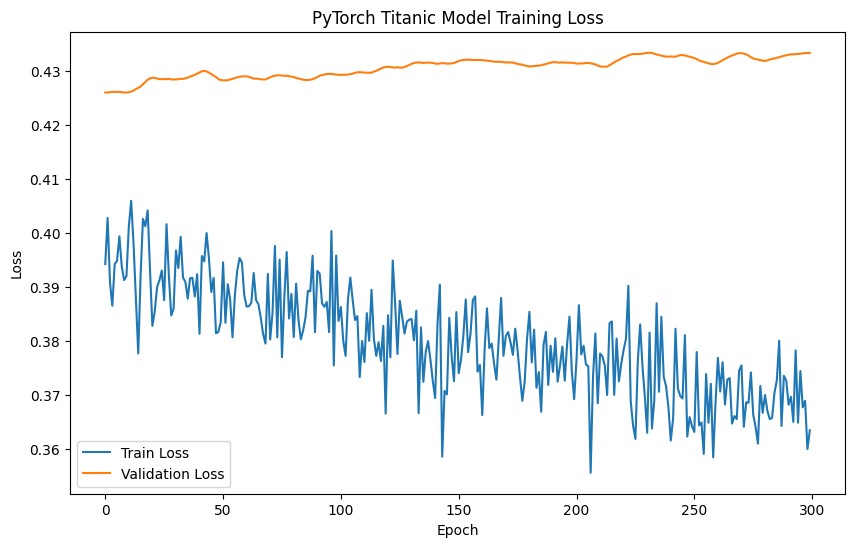

In [20]:
plt.figure(figsize=(10, 6))

# 학습 손실 그래프
plt.plot(train_loss_history, label="Train Loss")

# 검증 손실 그래프
plt.plot(valid_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch Titanic Model Training Loss")
plt.legend()
plt.show()

# 14. 성능 지표 시각화

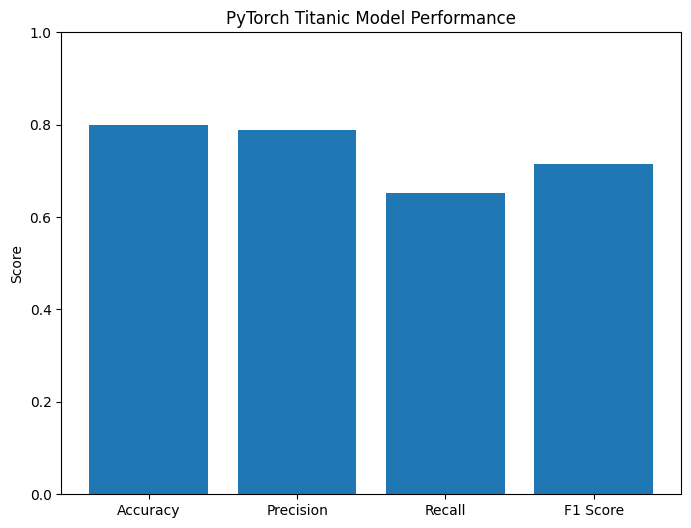

In [21]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(8, 6))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.title("PyTorch Titanic Model Performance")
plt.ylabel("Score")
plt.show()

# 15. Kaggle test.csv 데이터 전처리

In [27]:
# test 데이터 복사
test_processed = test_df.copy()

# -----------------------------
# 1. 결측치 처리
# -----------------------------

# Age 결측치는 test 데이터의 평균 나이로 채움
test_processed["Age"] = test_processed["Age"].fillna(test_processed["Age"].mean())

# Fare 결측치는 test 데이터의 평균 요금으로 채움
test_processed["Fare"] = test_processed["Fare"].fillna(test_processed["Fare"].mean())

# Embarked 결측치는 가장 많이 나온 값으로 채움
test_processed["Embarked"] = test_processed["Embarked"].fillna(test_processed["Embarked"].mode()[0])

# Cabin 결측치는 Unknown으로 채움
test_processed["Cabin"] = test_processed["Cabin"].fillna("Unknown")


# -----------------------------
# 2. 범주형 데이터 인코딩
# -----------------------------

for col in COL_CAT:
    # test 값들을 문자열로 변환
    # 숫자/문자 혼합으로 인한 오류를 방지
    test_processed[col] = test_processed[col].astype(str)

    # train에서 학습된 클래스도 문자열로 변환
    label_encoders[col].classes_ = label_encoders[col].classes_.astype(str)

    # train에서 학습된 범주 목록
    known_classes = set(label_encoders[col].classes_)

    # test에 train에는 없던 값이 있으면 첫 번째 기존 값으로 대체
    # 예: Parch 값 9가 train에 없으면 0 같은 기존 값으로 변경
    test_processed[col] = test_processed[col].apply(
        lambda x: x if x in known_classes else label_encoders[col].classes_[0]
    )

    # 안전하게 Label Encoding 수행
    test_processed[col] = label_encoders[col].transform(test_processed[col])


# -----------------------------
# 3. 수치형 데이터 스케일링
# -----------------------------

# train 데이터에서 학습한 scaler를 test에도 그대로 적용
test_processed[COL_NUM] = scaler.transform(test_processed[COL_NUM])


# -----------------------------
# 4. 예측용 입력 데이터 생성
# -----------------------------

# 학습 때 사용하지 않은 컬럼 제거
X_test_final = test_processed.drop(COL_DEL, axis=1)

# 학습 데이터와 컬럼 순서를 동일하게 맞춤
X_test_final = X_test_final[X_train.columns]


# -----------------------------
# 5. PyTorch Tensor 변환
# -----------------------------

X_test_final_tensor = torch.tensor(
    X_test_final.values,
    dtype=torch.float32
).to(device)

print("X_test_final_tensor shape:", X_test_final_tensor.shape)


X_test_final_tensor shape: torch.Size([418, 7])


# 16. test.csv 생존 여부 예측

In [28]:
model.eval()

with torch.no_grad():
    test_outputs = model(X_test_final_tensor)
    _, test_predictions = torch.max(test_outputs, 1)

# 예측 결과를 NumPy 배열로 변환
test_predictions = test_predictions.cpu().numpy()

print(test_predictions[:20])

[0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0 0]


# 17. 제출용 CSV 생성

In [30]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

submission.to_csv("titanic_pytorch_submission.csv", index=False)

print(submission.head())
print("titanic_pytorch_submission.csv 파일이 생성되었습니다.")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
titanic_pytorch_submission.csv 파일이 생성되었습니다.
